# Lesson 10 - The MLP Forward Pass

**Phase 1: The First Networks** &nbsp;|&nbsp; Deep Learning From Scratch

> Stack layers to break the XOR wall; trace one input to one output.

Runs top to bottom on Kaggle, Colab or locally. Nothing to download.

---

## 1. Plan

**What we build today**

The general multi-layer network. Lesson 09 placed hidden weights by hand;
today we write the real thing — matrices, layers, arbitrary widths — and
**trace a single input all the way to the output by hand**, every
intermediate number written down. That trace is not just for today: Lesson
11 differentiates this exact network, using these exact numbers, so getting
comfortable with it now pays twice.

**Why it exists**

Lesson 09 proved a single layer cannot represent XOR, and showed that two
hand-placed units could. This lesson generalises that from "a trick that
worked once" to "an architecture", and establishes the two facts that govern
everything after it:

1. **The nonlinearity is not optional.** Stack linear layers and they
   collapse: $W_2(W_1 x) = (W_2W_1)x$ is one linear layer wearing a costume.
   A hundred-layer linear network has exactly the expressive power of
   Lesson 06. We will collapse one numerically in section 9.1.
2. **Convexity is gone, permanently.** Lessons 06–08 had one minimum and a
   guarantee. From here there are many minima, saddle points everywhere, and
   no guarantee at all — and we can *prove* non-convexity in three lines
   using nothing but the fact that hidden units are interchangeable.

**What breaks without it**

Shape errors, mostly, and they are the reason section 2.2 labours the
dimensions. But the subtler breakage is conceptual: without a clear picture
of the forward pass as *a chain of composed functions*, backpropagation in
Lesson 11 is impossible to follow. Backprop is just the chain rule applied
to this chain. Build the chain carefully today and tomorrow is bookkeeping.

## 2. From scratch: the maths

### 2.1 One layer

A layer is an **affine map followed by an elementwise nonlinearity**:

$$\mathbf{z} = W^\top\mathbf{x} + \mathbf{b}, \qquad \mathbf{a} = \phi(\mathbf{z})$$

Two separate steps, and keeping them separate matters enormously for Lesson
11 — the derivative of the affine part and the derivative of $\phi$ are
computed separately and multiplied.

$\phi$ is applied **elementwise**: $\phi([z_1, z_2]) = [\phi(z_1), \phi(z_2)]$.
It never mixes units. All the mixing happens in $W$; all the bending happens
in $\phi$.

### 2.2 Shapes, stated once and obeyed forever

For a layer with $n_{\text{in}}$ inputs and $n_{\text{out}}$ units:

| object | shape | meaning of each axis |
|---|---|---|
| $\mathbf{x}$ | $(n_{\text{in}},)$ | one sample's features |
| $W$ | $(n_{\text{in}}, n_{\text{out}})$ | $W_{ij}$: input $i$ → unit $j$ |
| $\mathbf{b}$ | $(n_{\text{out}},)$ | one bias per unit |
| $\mathbf{z}, \mathbf{a}$ | $(n_{\text{out}},)$ | one value per unit |

Written out index by index, so there is no ambiguity about which way round
$W$ goes:

$$z_j = \sum_{i=1}^{n_{\text{in}}} x_i W_{ij} + b_j$$

For a **batch** of $m$ samples, stack them as rows — $X$ has shape
$(m, n_{\text{in}})$ — and the whole layer is one matrix product:

$$Z = XW + \mathbf{b}, \qquad (m, n_{\text{in}})\times(n_{\text{in}}, n_{\text{out}}) \rightarrow (m, n_{\text{out}})$$

where $\mathbf{b}$ of shape $(n_{\text{out}},)$ **broadcasts** down the rows,
exactly as in Lesson 01 §2.5 — the same bias added to every sample.

> Convention warning. Many textbooks write $\mathbf{z} = W\mathbf{x}+\mathbf{b}$
> with $W$ of shape $(n_{\text{out}}, n_{\text{in}})$ and samples as columns.
> Both are correct; mixing them is the single most common source of
> transpose bugs. **We use rows-are-samples throughout this course**, which
> is also what Keras and PyTorch do.

### 2.3 The network

For our 2–2–1 network:

$$\mathbf{z}^{(1)} = W_1^\top\mathbf{x} + \mathbf{b}_1,\qquad \mathbf{h} = \tanh\!\left(\mathbf{z}^{(1)}\right)$$

$$z^{(2)} = W_2^\top\mathbf{h} + b_2,\qquad \hat{y} = \sigma\!\left(z^{(2)}\right)$$

$\tanh$ in the hidden layer (a *choice*, revisited in Lesson 12), sigmoid at
the output (*not* a choice — it is what makes the output a probability, per
Lesson 08). Recall $\tanh(z) = \frac{e^{z}-e^{-z}}{e^{z}+e^{-z}}$, which maps
to $(-1, 1)$ and is zero-centred, unlike the sigmoid.

### 2.4 Why the nonlinearity is compulsory

Drop $\phi$ and compose two layers:

$$\mathbf{z}^{(2)} = W_2^\top\left(W_1^\top\mathbf{x} + \mathbf{b}_1\right) + \mathbf{b}_2
 = \underbrace{\left(W_2^\top W_1^\top\right)}_{W_{\text{eq}}^\top}\mathbf{x}
 + \underbrace{\left(W_2^\top\mathbf{b}_1 + \mathbf{b}_2\right)}_{\mathbf{b}_{\text{eq}}}$$

A single affine map. **Depth bought nothing.** By induction this holds for
any number of layers: a purely linear network of any depth is exactly as
expressive as Lesson 06's one-liner, and would fail XOR for exactly the
reason proved in Lesson 09.

$\phi$ is what stops the collapse. It is the entire reason deep networks are
more than a slow way to do linear regression.

### 2.5 Convexity is gone — a proof in three lines

Take any trained network. **Swap hidden unit 1 with hidden unit 2** —
exchange the corresponding columns of $W_1$, entries of $\mathbf{b}_1$, and
rows of $W_2$. The function computed is *identical*, so the loss is
identical. Call these parameter vectors $\theta$ and $\theta'$.

For a 2-unit hidden layer there are $2! = 2$ such arrangements; for width
$n$ there are $n!$, and sign-flip symmetries of $\tanh$ multiply that by
$2^n$. A width-100 layer therefore has at least $100!\times 2^{100} > 10^{188}$
parameter settings computing the *same function*.

Now, a convex function has a convex set of minimisers, so the midpoint
$\tfrac12(\theta + \theta')$ would have to be a minimiser too. It generally
is not — averaging two different-but-equivalent networks produces a network
that computes something else entirely, usually worse. **Therefore the loss
is not convex.** Section 4.4 shows the bump.

The practical consequences run through the rest of the course: initialization
suddenly matters (Lesson 14), optimizers must cope with saddle points
(Lesson 15), and "the minimum" becomes "a minimum".

## 3. Numerical: worked by hand

The network we will trace — and which Lesson 11 will differentiate.

### 3.1 The parameters and the input

$$W_1 = \begin{bmatrix} 0.5 & -1.0 \\ -0.5 & 0.5 \end{bmatrix},\quad
  \mathbf{b}_1 = \begin{bmatrix} 0.0 \\ 1.0 \end{bmatrix},\quad
  W_2 = \begin{bmatrix} 1.0 \\ 2.0 \end{bmatrix},\quad b_2 = -0.5$$

Input $\mathbf{x} = [1, 2]$, true label $y = 1$.

Read $W_1$ by columns: column $j$ holds the weights *into* hidden unit $j$.
So unit 1 receives $(0.5, -0.5)$ and unit 2 receives $(-1.0, 0.5)$.

### 3.2 Hidden pre-activations

$$z^{(1)}_1 = x_1 W_{1,11} + x_2 W_{1,21} + b_{1,1} = (1)(0.5) + (2)(-0.5) + 0.0 = 0.5 - 1.0 = -0.5$$

$$z^{(1)}_2 = x_1 W_{1,12} + x_2 W_{1,22} + b_{1,2} = (1)(-1.0) + (2)(0.5) + 1.0 = -1.0 + 1.0 + 1.0 = 1.0$$

$$\mathbf{z}^{(1)} = [-0.5,\ 1.0]$$

### 3.3 Hidden activations

$$h_1 = \tanh(-0.5) = -0.4621171573, \qquad h_2 = \tanh(1.0) = 0.7615941560$$

The nonlinearity has done its work: the *ratio* between the two units is no
longer the ratio of their pre-activations. $z_2/z_1 = -2$ but
$h_2/h_1 = -1.648$. **That distortion is the whole point** — it is the only
thing a linear layer could not have done.

### 3.4 Output

$$z^{(2)} = h_1 W_{2,1} + h_2 W_{2,2} + b_2 = (-0.4621171573)(1.0) + (0.7615941560)(2.0) - 0.5$$

$$= -0.4621171573 + 1.5231883120 - 0.5 = 0.5610711547$$

$$\hat{y} = \sigma(0.5610711547) = 0.6367003486$$

### 3.5 The loss

With $y = 1$, binary cross-entropy from Lesson 08 keeps only the first term:

$$L = -\log\hat{y} = -\log(0.6367003486) = 0.4514561445$$

Better than the $\log 2 = 0.693$ of total ignorance, so this untrained
network is already leaning the right way on this sample — by luck.

**The numbers every implementation must reproduce:**
$\mathbf{z}^{(1)} = [-0.5, 1.0]$, $\mathbf{h} = [-0.4621171573, 0.7615941560]$,
$z^{(2)} = 0.5610711547$, $\hat{y} = 0.6367003486$, $L = 0.4514561445$.

In [1]:
# Setup -- the only cell with imports.
import math

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({
    "figure.figsize": (9, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 110,
    "font.size": 9,
})

# The network of section 3. Lesson 11 differentiates exactly this.
W1 = [[0.5, -1.0],
      [-0.5, 0.5]]        # W1[i][j]: input i -> hidden unit j
B1 = [0.0, 1.0]
W2 = [1.0, 2.0]           # hidden unit j -> output
B2 = -0.5
X_IN = [1.0, 2.0]
Y_TRUE = 1.0

TRUTH = {
    "z1": [-0.5, 1.0],
    "h":  [-0.4621171573, 0.7615941560],
    "z2": 0.5610711547,
    "yhat": 0.6367003486,
    "loss": 0.4514561445,
}
for k, v in TRUTH.items():
    print(f"  {k:<5} = {v}")

  z1    = [-0.5, 1.0]
  h     = [-0.4621171573, 0.761594156]
  z2    = 0.5610711547
  yhat  = 0.6367003486
  loss  = 0.4514561445


## 4. Visualization

### 4.1 The network, drawn with the actual numbers on it

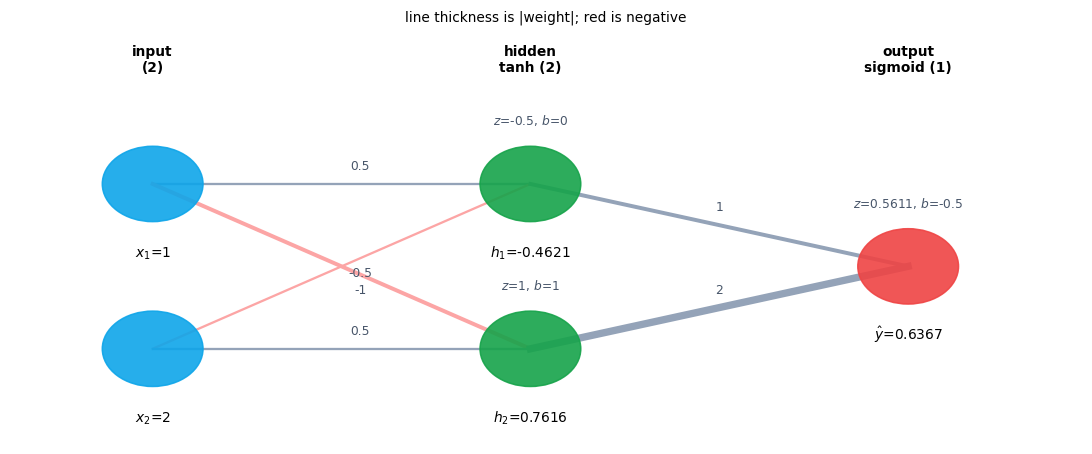

  9 parameters in total: 4 in W1 + 2 in b1 + 2 in W2 + 1 in b2


In [2]:
fig, ax = plt.subplots(figsize=(10, 4.2))
layers = {0: [(0.0, 2.2), (0.0, 0.8)], 1: [(2.4, 2.2), (2.4, 0.8)], 2: [(4.8, 1.5)]}
labels = {0: [f"$x_1$={X_IN[0]:g}", f"$x_2$={X_IN[1]:g}"],
          1: [f"$h_1$={TRUTH['h'][0]:.4f}", f"$h_2$={TRUTH['h'][1]:.4f}"],
          2: [f"$\\hat{{y}}$={TRUTH['yhat']:.4f}"]}
colours = {0: "#0ea5e9", 1: "#16a34a", 2: "#ef4444"}

for i, (xi, yi) in enumerate(layers[0]):
    for j, (xj, yj) in enumerate(layers[1]):
        w = W1[i][j]
        ax.plot([xi, xj], [yi, yj], color="#94a3b8" if w > 0 else "#fca5a5",
                lw=abs(w) * 2.2 + 0.4, zorder=1)
        ax.text(xi + (xj - xi) * 0.55, yi + (yj - yi) * 0.55 + (0.12 if i == j else -0.16),
                f"{w:g}", fontsize=8, color="#475569", ha="center")
for j, (xj, yj) in enumerate(layers[1]):
    ax.plot([xj, layers[2][0][0]], [yj, layers[2][0][1]], color="#94a3b8",
            lw=abs(W2[j]) * 2.2 + 0.4, zorder=1)
    ax.text(xj + 1.2, yj + (layers[2][0][1] - yj) * 0.5 + 0.12, f"{W2[j]:g}",
            fontsize=8, color="#475569", ha="center")

for li, nodes in layers.items():
    for k, (nx, ny) in enumerate(nodes):
        ax.add_patch(plt.Circle((nx, ny), 0.32, color=colours[li], zorder=3, alpha=.9))
        ax.text(nx, ny - 0.62, labels[li][k], ha="center", fontsize=9)
        if li == 1:
            ax.text(nx, ny + 0.5, f"$z$={TRUTH['z1'][k]:g}, $b$={B1[k]:g}",
                    ha="center", fontsize=8, color="#475569")
        if li == 2:
            ax.text(nx, ny + 0.5, f"$z$={TRUTH['z2']:.4f}, $b$={B2:g}",
                    ha="center", fontsize=8, color="#475569")

for lx, name in [(0.0, "input\n(2)"), (2.4, "hidden\ntanh (2)"), (4.8, "output\nsigmoid (1)")]:
    ax.text(lx, 3.15, name, ha="center", fontsize=9, weight="bold")
ax.set_xlim(-0.9, 5.9); ax.set_ylim(0.0, 3.5); ax.axis("off")
plt.title("line thickness is |weight|; red is negative", fontsize=9)
plt.tight_layout(); plt.show()

print(f"  9 parameters in total: {2*2} in W1 + {2} in b1 + {2} in W2 + 1 in b2")

### 4.2 What the hidden layer does to the input space

The hidden layer *bends* the plane. Straight lines in the input become
curves in hidden space — and that bending is what lets a straight output
boundary carve a curved region back in the input.

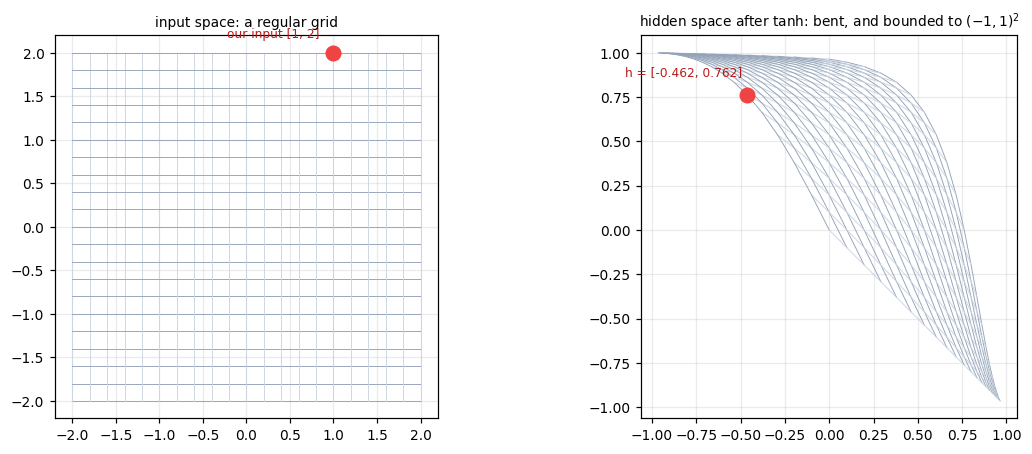

The grid gets squashed towards the corners of a square, because tanh
saturates. Note what that costs: points far apart in the input become nearly
identical in hidden space. Information is being destroyed out there, and the
gradient that flows back through it will be nearly zero -- Lesson 12's
subject, and the reason ReLU eventually replaced tanh.


In [3]:
gx = np.linspace(-2, 2, 21)
GX, GY = np.meshgrid(gx, gx)
W1a, B1a = np.array(W1), np.array(B1)
pts = np.stack([GX.ravel(), GY.ravel()], axis=1)
H = np.tanh(pts @ W1a + B1a)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11, 4.2))
for ax, data, title in [
    (ax0, pts, "input space: a regular grid"),
    (ax1, H, "hidden space after tanh: bent, and bounded to $(-1,1)^2$"),
]:
    n = len(gx)
    for r in range(n):
        ax.plot(data[r * n:(r + 1) * n, 0], data[r * n:(r + 1) * n, 1],
                color="#94a3b8", lw=.6)
        ax.plot(data[r::n, 0], data[r::n, 1], color="#cbd5e1", lw=.6)
    ax.set_title(title, fontsize=9); ax.set_aspect("equal")

hx = np.tanh(np.array(X_IN) @ W1a + B1a)
ax0.scatter([X_IN[0]], [X_IN[1]], s=90, color="#ef4444", zorder=5)
ax0.annotate("our input [1, 2]", (X_IN[0], X_IN[1]), textcoords="offset points",
             xytext=(-70, 10), fontsize=8, color="#b91c1c")
ax1.scatter([hx[0]], [hx[1]], s=90, color="#ef4444", zorder=5)
ax1.annotate(f"h = [{hx[0]:.3f}, {hx[1]:.3f}]", (hx[0], hx[1]),
             textcoords="offset points", xytext=(-80, 12), fontsize=8, color="#b91c1c")
plt.tight_layout(); plt.show()

print("""The grid gets squashed towards the corners of a square, because tanh
saturates. Note what that costs: points far apart in the input become nearly
identical in hidden space. Information is being destroyed out there, and the
gradient that flows back through it will be nearly zero -- Lesson 12's
subject, and the reason ReLU eventually replaced tanh.""")

### 4.3 The same architecture, trained, solving XOR

Lesson 09 placed these weights by hand. Here gradient descent finds them,
and the decision boundary is visibly *curved* — something no single layer
could produce.

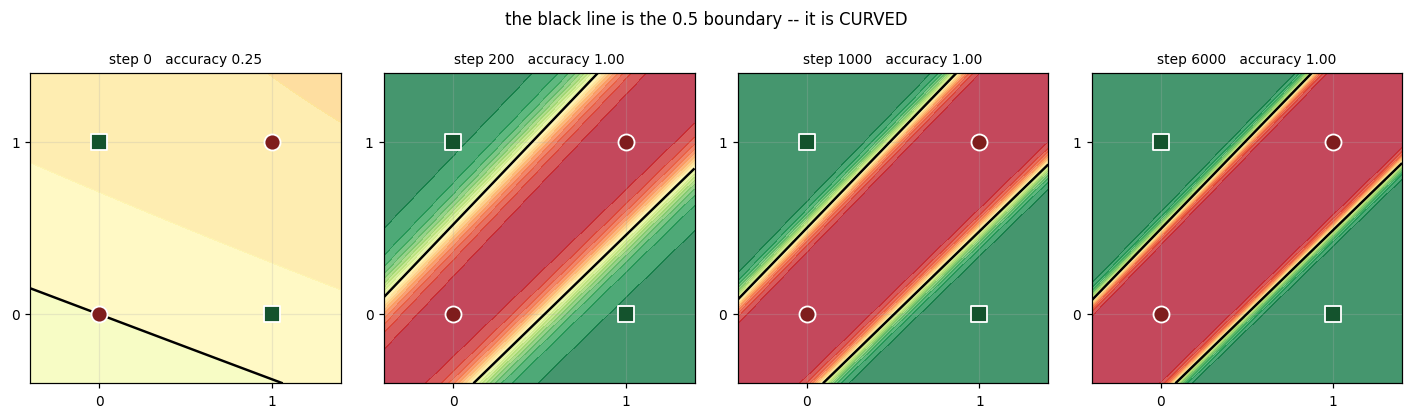

  final predictions: [4.000e-04 9.993e-01 9.993e-01 3.000e-04]
  XOR targets      : [0. 1. 1. 0.]

  Two hidden units, nine parameters, and the wall from Lesson 09 is gone.


In [4]:
Xxor = np.array([[0., 0.], [0., 1.], [1., 0.], [1., 1.]])
yxor = np.array([0., 1., 1., 0.])


def forward(Wa, ba, Wb, bb, X):
    Hh = np.tanh(X @ Wa + ba)
    return Hh, 1 / (1 + np.exp(-(Hh @ Wb + bb)))


rng = np.random.default_rng(0)      # see section 9.3: not every seed works
Wa = rng.normal(0, 1, (2, 2)); ba = np.zeros(2)
Wb = rng.normal(0, 1, (2, 1)); bb = np.zeros(1)

snapshots = {}
for step in range(6001):
    Hh, p = forward(Wa, ba, Wb, bb, Xxor)
    if step in (0, 200, 1000, 6000):
        snapshots[step] = (Wa.copy(), ba.copy(), Wb.copy(), bb.copy())
    d2 = (p - yxor[:, None]) / len(Xxor)          # Lesson 08's (sigma - y)
    dWb, dbb = Hh.T @ d2, d2.sum(0)
    d1 = (d2 @ Wb.T) * (1 - Hh ** 2)              # tanh' = 1 - tanh^2
    dWa, dba = Xxor.T @ d1, d1.sum(0)
    Wa -= 1.0 * dWa; ba -= 1.0 * dba
    Wb -= 1.0 * dWb; bb -= 1.0 * dbb

fig, axes = plt.subplots(1, 4, figsize=(13, 3.4))
gg = np.linspace(-.4, 1.4, 160)
GGX, GGY = np.meshgrid(gg, gg)
grid = np.stack([GGX.ravel(), GGY.ravel()], axis=1)
for ax, (step, (wa, b_a, wb, b_b)) in zip(axes, snapshots.items()):
    _, pg = forward(wa, b_a, wb, b_b, grid)
    ax.contourf(GGX, GGY, pg.reshape(GGX.shape), levels=np.linspace(0, 1, 21),
                cmap="RdYlGn", alpha=.75)
    ax.contour(GGX, GGY, pg.reshape(GGX.shape), levels=[0.5], colors="black", linewidths=1.6)
    ax.scatter(Xxor[yxor == 0, 0], Xxor[yxor == 0, 1], s=110, color="#7f1d1d",
               edgecolor="white", lw=1.2, zorder=5)
    ax.scatter(Xxor[yxor == 1, 0], Xxor[yxor == 1, 1], s=110, color="#14532d",
               marker="s", edgecolor="white", lw=1.2, zorder=5)
    _, pp = forward(wa, b_a, wb, b_b, Xxor)
    acc = float(np.mean((pp.ravel() >= .5) == yxor))
    ax.set_title(f"step {step}   accuracy {acc:.2f}", fontsize=9)
    ax.set_xticks([0, 1]); ax.set_yticks([0, 1]); ax.set_aspect("equal")
plt.suptitle("the black line is the 0.5 boundary -- it is CURVED", y=1.04)
plt.tight_layout(); plt.show()

_, final = forward(Wa, ba, Wb, bb, Xxor)
print(f"  final predictions: {np.round(final.ravel(), 4)}")
print(f"  XOR targets      : {yxor}")
assert np.all((final.ravel() >= .5) == yxor), "the trained MLP should solve XOR"
print("\n  Two hidden units, nine parameters, and the wall from Lesson 09 is gone.")

### 4.4 Non-convexity, made visible

Section 2.5 argued that swapping two hidden units gives a different
parameter vector with identical loss. Here we take the straight line
*between* those two settings and evaluate the loss along it. A convex
function could never rise in the middle.

  loss of the trained network        : 0.00051706
  loss with hidden units 1 and 2 swapped: 0.00051706


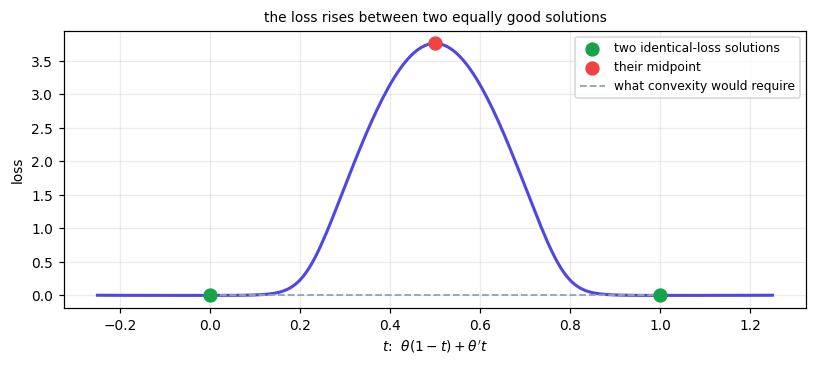

  loss at the endpoints : 0.00052285
  loss at the midpoint  : 3.75745207
  a convex function could not exceed 0.00052285 anywhere between them.

  Averaging two good networks gave a worse one. This is not a quirk of our
  particular run -- it follows from permutation symmetry, so it is true of
  EVERY network with more than one hidden unit. Convexity is gone for good,
  and that is why the rest of this course cares so much about initialization
  and optimizers.


In [5]:
def xor_loss(wa, b_a, wb, b_b):
    _, p = forward(wa, b_a, wb, b_b, Xxor)
    p = np.clip(p.ravel(), 1e-12, 1 - 1e-12)
    return float(-np.mean(yxor * np.log(p) + (1 - yxor) * np.log(1 - p)))


# theta' = the same network with its two hidden units exchanged
Wa_s, ba_s, Wb_s = Wa[:, ::-1].copy(), ba[::-1].copy(), Wb[::-1].copy()
print(f"  loss of the trained network        : {xor_loss(Wa, ba, Wb, bb):.8f}")
print(f"  loss with hidden units 1 and 2 swapped: {xor_loss(Wa_s, ba_s, Wb_s, bb):.8f}")
assert abs(xor_loss(Wa, ba, Wb, bb) - xor_loss(Wa_s, ba_s, Wb_s, bb)) < 1e-12

ts = np.linspace(-0.25, 1.25, 240)
losses = [xor_loss(Wa * (1 - t) + Wa_s * t, ba * (1 - t) + ba_s * t,
                   Wb * (1 - t) + Wb_s * t, bb) for t in ts]

plt.figure(figsize=(7.5, 3.4))
plt.plot(ts, losses, color="#4f46e5", lw=2)
plt.scatter([0, 1], [losses[np.argmin(np.abs(ts))], losses[np.argmin(np.abs(ts - 1))]],
            color="#16a34a", s=70, zorder=5, label="two identical-loss solutions")
mid = losses[np.argmin(np.abs(ts - 0.5))]
plt.scatter([0.5], [mid], color="#ef4444", s=70, zorder=5, label="their midpoint")
plt.plot([0, 1], [losses[np.argmin(np.abs(ts))], losses[np.argmin(np.abs(ts - 1))]],
         "--", color="#94a3b8", lw=1.2, label="what convexity would require")
plt.xlabel(r"$t$:  $\theta(1-t) + \theta' t$"); plt.ylabel("loss")
plt.title("the loss rises between two equally good solutions", fontsize=9)
plt.legend(fontsize=8); plt.tight_layout(); plt.show()

end = losses[np.argmin(np.abs(ts))]
print(f"  loss at the endpoints : {end:.8f}")
print(f"  loss at the midpoint  : {mid:.8f}")
print(f"  a convex function could not exceed {end:.8f} anywhere between them.")
assert mid > end, "the midpoint must be worse, proving non-convexity"
print("""
  Averaging two good networks gave a worse one. This is not a quirk of our
  particular run -- it follows from permutation symmetry, so it is true of
  EVERY network with more than one hidden unit. Convexity is gone for good,
  and that is why the rest of this course cares so much about initialization
  and optimizers.""")

## 5. Scratch code — pure Python, no imports

The forward pass with explicit loops, so every index in section 2.2 is
visible. This must reproduce section 3 exactly.

In [6]:
def tanh(z):
    """(e^z - e^-z)/(e^z + e^-z), written to avoid overflow for large |z|."""
    if z > 20:
        return 1.0
    if z < -20:
        return -1.0
    e2 = math.exp(2 * z)
    return (e2 - 1) / (e2 + 1)


def sigmoid(z):
    if z >= 0:
        return 1.0 / (1.0 + math.exp(-z))
    t = math.exp(z)
    return t / (1.0 + t)


def dense(x, W, b, activation):
    """One layer: z_j = sum_i x_i W[i][j] + b_j, then a_j = phi(z_j)."""
    n_out = len(b)
    z = [sum(x[i] * W[i][j] for i in range(len(x))) + b[j] for j in range(n_out)]
    return z, [activation(v) for v in z]


def forward_scratch(x, W1, b1, W2, b2):
    z1, h = dense(x, W1, b1, tanh)
    z2, out = dense(h, [[w] for w in W2], [b2], sigmoid)
    return z1, h, z2[0], out[0]


z1_s, h_s, z2_s, yhat_s = forward_scratch(X_IN, W1, B1, W2, B2)
loss_s = -(Y_TRUE * math.log(yhat_s) + (1 - Y_TRUE) * math.log(1 - yhat_s))

scratch = {"z1": z1_s, "h": h_s, "z2": z2_s, "yhat": yhat_s, "loss": loss_s}

print(f"  {'quantity':<6} {'computed':>28} {'by hand':>28}")
print("  " + "-" * 64)
for k in TRUTH:
    a, b = scratch[k], TRUTH[k]
    fmt = lambda v: ("[" + ", ".join(f"{q:.10f}" for q in v) + "]") if isinstance(v, list) else f"{v:.10f}"
    ok = (all(abs(p - q) < 1e-9 for p, q in zip(a, b)) if isinstance(a, list)
          else abs(a - b) < 1e-9)
    print(f"  {('OK ' if ok else 'XX ') + k:<6} {fmt(a):>28} {fmt(b):>28}")
    assert ok, f"scratch {k}"

print("\n  A single input traced through nine parameters, by hand and by code.")

  quantity                     computed                      by hand
  ----------------------------------------------------------------
  OK z1  [-0.5000000000, 1.0000000000] [-0.5000000000, 1.0000000000]
  OK h   [-0.4621171573, 0.7615941560] [-0.4621171573, 0.7615941560]
  OK z2                  0.5610711547                 0.5610711547
  OK yhat                 0.6367003486                 0.6367003486
  OK loss                 0.4514561445                 0.4514561445

  A single input traced through nine parameters, by hand and by code.


## 6. NumPy — vectorized

The loops become two matrix products. Crucially, the **same code handles a
whole batch** — that is the payoff of the shape conventions in section 2.2.

In [7]:
W1n, b1n = np.array(W1), np.array(B1)
W2n, b2n = np.array(W2).reshape(2, 1), np.array([B2])
xn = np.array(X_IN)


def forward_np(X):
    X = np.atleast_2d(X)
    Z1 = X @ W1n + b1n                      # (m,2)@(2,2) + (2,) -> (m,2)
    Hh = np.tanh(Z1)
    Z2 = Hh @ W2n + b2n                     # (m,2)@(2,1) + (1,) -> (m,1)
    return Z1, Hh, Z2, 1 / (1 + np.exp(-Z2))


Z1, Hn, Z2, P = forward_np(xn)
numpy_res = {
    "z1": Z1[0].tolist(), "h": Hn[0].tolist(),
    "z2": float(Z2[0, 0]), "yhat": float(P[0, 0]),
    "loss": float(-(Y_TRUE * np.log(P[0, 0]) + (1 - Y_TRUE) * np.log(1 - P[0, 0]))),
}
for k in TRUTH:
    a, b = numpy_res[k], TRUTH[k]
    ok = (all(abs(p - q) < 1e-9 for p, q in zip(a, b)) if isinstance(a, list)
          else abs(a - b) < 1e-9)
    assert ok, f"numpy {k}"
print("  every value matches the hand calculation")

# the same function, on a batch of five, with no code change
batch = np.array([[1., 2.], [0., 0.], [-1., 1.], [2., -1.], [0.5, 0.5]])
_, Hb, _, Pb = forward_np(batch)
print(f"\n  batch of {len(batch)}: X{batch.shape} -> H{Hb.shape} -> P{Pb.shape}")
for row, h, p in zip(batch, Hb, Pb):
    print(f"    x = {str(row):<12} h = [{h[0]:>8.5f}, {h[1]:>8.5f}]  yhat = {p[0]:.6f}")
assert abs(Pb[0, 0] - TRUTH["yhat"]) < 1e-9

  every value matches the hand calculation

  batch of 5: X(5, 2) -> H(5, 2) -> P(5, 1)
    x = [1. 2.]      h = [-0.46212,  0.76159]  yhat = 0.636700
    x = [0. 0.]      h = [ 0.00000,  0.76159]  yhat = 0.735593
    x = [-1.  1.]    h = [-0.76159,  0.98661]  yhat = 0.670762
    x = [ 2. -1.]    h = [ 0.90515, -0.90515]  yhat = 0.197000
    x = [0.5 0.5]    h = [ 0.00000,  0.63515]  yhat = 0.683585


## 7. TensorFlow

In [8]:
try:
    import tensorflow as tf
    HAS_TF = True
    print(f"TensorFlow {tf.__version__}")
except ImportError:
    HAS_TF = False
    print("TensorFlow not installed locally -- section skipped. It runs on Kaggle.")

TensorFlow not installed locally -- section skipped. It runs on Kaggle.


In [9]:
if HAS_TF:
    model = tf.keras.Sequential([
        tf.keras.layers.Dense(2, activation="tanh", input_shape=(2,), name="hidden"),
        tf.keras.layers.Dense(1, activation="sigmoid", name="out"),
    ])
    # Keras stores kernels as (n_in, n_out) -- exactly our convention.
    model.get_layer("hidden").set_weights([np.array(W1), np.array(B1)])
    model.get_layer("out").set_weights([np.array(W2).reshape(2, 1), np.array([B2])])

    hidden_model = tf.keras.Model(model.input, model.get_layer("hidden").output)
    h_tf = hidden_model.predict(np.array([X_IN]), verbose=0)[0]
    p_tf = model.predict(np.array([X_IN]), verbose=0)[0, 0]
    l_tf = float(tf.keras.losses.binary_crossentropy(
        np.array([[Y_TRUE]]), np.array([[p_tf]])).numpy()[0])

    tf_res = {
        "z1": np.arctanh(np.clip(h_tf, -1 + 1e-12, 1 - 1e-12)).tolist(),
        "h": h_tf.tolist(),
        "z2": float(np.log(p_tf / (1 - p_tf))),
        "yhat": float(p_tf), "loss": l_tf,
    }
    for k in TRUTH:
        v = tf_res[k]
        print(f"  {k:<5} = " + (f"[{v[0]:.10f}, {v[1]:.10f}]" if isinstance(v, list) else f"{v:.10f}"))
    print(f"\n  parameter count: {model.count_params()}   (we counted 9 by hand)")
    assert model.count_params() == 9
else:
    tf_res = None

## 8. Agreement check

In [10]:
implementations = {"hand (section 3)": TRUTH, "scratch": scratch, "numpy": numpy_res}
if tf_res is not None:
    implementations["tensorflow"] = tf_res

flat_keys = ["z1[0]", "z1[1]", "h[0]", "h[1]", "z2", "yhat", "loss"]


def pick(impl, key):
    if key.startswith("z1["):
        return impl["z1"][int(key[3])]
    if key.startswith("h["):
        return impl["h"][int(key[2])]
    return impl[key]


print(f"{'quantity':<8} " + " ".join(f"{n:>18}" for n in implementations))
print("-" * (9 + 19 * len(implementations)))
for k in flat_keys:
    print(f"{k:<8} " + " ".join(f"{pick(impl, k):>18.10f}" for impl in implementations.values()))

for name, impl in implementations.items():
    for k in flat_keys:
        assert abs(pick(impl, k) - pick(TRUTH, k)) < 1e-6, f"{name} disagrees on {k}"

skipped = "" if tf_res is not None else "   (tensorflow skipped -- not installed locally)"
print(f"\nAll implementations agree to 1e-6.{skipped}")

quantity   hand (section 3)            scratch              numpy
------------------------------------------------------------------
z1[0]         -0.5000000000      -0.5000000000      -0.5000000000
z1[1]          1.0000000000       1.0000000000       1.0000000000
h[0]          -0.4621171573      -0.4621171573      -0.4621171573
h[1]           0.7615941560       0.7615941560       0.7615941560
z2             0.5610711547       0.5610711547       0.5610711547
yhat           0.6367003486       0.6367003486       0.6367003486
loss           0.4514561445       0.4514561445       0.4514561445

All implementations agree to 1e-6.   (tensorflow skipped -- not installed locally)


## 9. The silent failures

### 9.1 Forget the activation and the network collapses

No error, no warning. The model simply becomes linear regression with extra
steps — and will fail XOR exactly as Lesson 09 proved a single layer must.

In [11]:
Wprod = W1n @ W2n                               # (2,2) @ (2,1) -> (2,1)
bprod = float(b1n @ W2n + b2n)

print("  a 2-layer LINEAR network (no tanh) on our input:")
lin_out = float(xn @ W1n @ W2n + (b1n @ W2n + b2n))
print(f"    two layers : x @ W1 @ W2 + ... = {lin_out:.10f}")
print(f"    ONE layer  : x @ {np.round(Wprod.ravel(), 4)} + {bprod:.4f} = "
      f"{float(xn @ Wprod + bprod):.10f}")
assert abs(lin_out - float(xn @ Wprod + bprod)) < 1e-12
print("    identical -- the second layer contributed nothing.")

# and it cannot learn XOR, however long you train it
Wa2 = rng.normal(0, 1, (2, 2)); ba2 = np.zeros(2)
Wb2 = rng.normal(0, 1, (2, 1)); bb2 = np.zeros(1)
for _ in range(20000):
    Hl = Xxor @ Wa2 + ba2                       # NO activation
    pl = 1 / (1 + np.exp(-(Hl @ Wb2 + bb2)))
    d2 = (pl - yxor[:, None]) / 4
    dWb2, dbb2 = Hl.T @ d2, d2.sum(0)
    d1 = d2 @ Wb2.T                             # no tanh' factor
    Wa2 -= .5 * (Xxor.T @ d1); ba2 -= .5 * d1.sum(0)
    Wb2 -= .5 * dWb2; bb2 -= .5 * dbb2
pl = 1 / (1 + np.exp(-((Xxor @ Wa2 + ba2) @ Wb2 + bb2)))
acc_lin = float(np.mean((pl.ravel() >= .5) == yxor))
print(f"\n  linear 2-layer net on XOR after 20,000 steps: accuracy {acc_lin:.2f}")
print(f"  predictions {np.round(pl.ravel(), 4)}  (all ~0.5 -- it has given up)")
assert acc_lin < 1.0
print("""
  Depth without nonlinearity is not depth. If a deep model performs exactly
  like a linear one, check that your activations are actually attached --
  `Dense(64)` with no `activation=` argument is linear, and that default has
  cost people weeks.""")

  a 2-layer LINEAR network (no tanh) on our input:
    two layers : x @ W1 @ W2 + ... = 1.0000000000
    ONE layer  : x @ [-1.5  0.5] + 1.5000 = 1.0000000000
    identical -- the second layer contributed nothing.


C:\Users\Utathya_Aich\AppData\Local\Temp\ipykernel_45540\192124792.py:2: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  bprod = float(b1n @ W2n + b2n)
C:\Users\Utathya_Aich\AppData\Local\Temp\ipykernel_45540\192124792.py:5: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  lin_out = float(xn @ W1n @ W2n + (b1n @ W2n + b2n))
C:\Users\Utathya_Aich\AppData\Local\Temp\ipykernel_45540\192124792.py:8: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  f"{float(xn @ Wprod + bprod):


  linear 2-layer net on XOR after 20,000 steps: accuracy 0.50
  predictions [0.5 0.5 0.5 0.5]  (all ~0.5 -- it has given up)

  Depth without nonlinearity is not depth. If a deep model performs exactly
  like a linear one, check that your activations are actually attached --
  `Dense(64)` with no `activation=` argument is linear, and that default has
  cost people weeks.


### 9.2 The transposed weight matrix that does not raise

A square hidden layer makes $W$ and $W^\top$ the same shape, so the wrong
one runs happily and silently computes a different function.

In [12]:
print(f"  correct     x @ W1  : {np.round(xn @ W1n + b1n, 6)}")
print(f"  transposed  x @ W1.T: {np.round(xn @ W1n.T + b1n, 6)}")
print("  Both valid, both silent, different answers.\n")

try:
    np.array([1., 2., 3.]) @ W1n
except ValueError as e:
    print(f"  A non-square mismatch DOES raise: {e}")

print("""
  The protection is not a try/except -- it is naming your axes and asserting
  shapes. Every layer in this course carries the comment
  "W[i][j]: input i -> unit j" for exactly this reason, and a one-line
  `assert Z.shape == (m, n_out)` after each layer catches it immediately.

  Note this is the same class of bug as Lesson 01 section 9: an operation
  that is valid, silent, and wrong.""")

  correct     x @ W1  : [-0.5  1. ]
  transposed  x @ W1.T: [-1.5  1.5]
  Both valid, both silent, different answers.

  A non-square mismatch DOES raise: matmul: Input operand 1 has a mismatch in its core dimension 0, with gufunc signature (n?,k),(k,m?)->(n?,m?) (size 2 is different from 3)

  The protection is not a try/except -- it is naming your axes and asserting
  shapes. Every layer in this course carries the comment
  "W[i][j]: input i -> unit j" for exactly this reason, and a one-line
  `assert Z.shape == (m, n_out)` after each layer catches it immediately.

  Note this is the same class of bug as Lesson 01 section 9: an operation
  that is valid, silent, and wrong.


### 9.3 Sometimes it simply does not converge

This is non-convexity's practical bill, and it arrives immediately. The
network in section 4.3 solved XOR — but change only the random seed, touch
nothing else, and it often will not.

In [13]:
def train_xor(seed, H=2, steps=4000, lr=1.0):
    r = np.random.default_rng(seed)
    Wa_, ba_ = r.normal(0, 1, (2, H)), np.zeros(H)
    Wb_, bb_ = r.normal(0, 1, (H, 1)), np.zeros(1)
    for _ in range(steps):
        Hh = np.tanh(Xxor @ Wa_ + ba_)
        p = 1 / (1 + np.exp(-(Hh @ Wb_ + bb_)))
        d2 = (p - yxor[:, None]) / 4
        d1 = (d2 @ Wb_.T) * (1 - Hh ** 2)
        Wb_ -= lr * (Hh.T @ d2); bb_ -= lr * d2.sum(0)
        Wa_ -= lr * (Xxor.T @ d1); ba_ -= lr * d1.sum(0)
    Hh = np.tanh(Xxor @ Wa_ + ba_)
    p = 1 / (1 + np.exp(-(Hh @ Wb_ + bb_)))
    return float(np.mean((p.ravel() >= .5) == yxor))


print("  identical architecture and hyperparameters, only the seed differs:")
outcomes = {s: train_xor(s) for s in range(10)}
for s, a in outcomes.items():
    print(f"    seed {s}: accuracy {a:.2f}" + ("   solved" if a == 1.0 else "   STUCK"))
rate = sum(1 for a in outcomes.values() if a == 1.0) / len(outcomes)
print(f"\n  success rate: {rate:.0%}")

print(f"\n  {'hidden units':>13} {'success rate':>14} {'note':<38}")
for H, note in [(1, "impossible: one unit = one boundary"),
                (2, "minimum that CAN work"),
                (4, "same expressiveness, easier to find"),
                (8, "same expressiveness, easier still")]:
    r = sum(1 for s in range(10) if train_xor(s, H=H) == 1.0) / 10
    print(f"  {H:>13} {r:>13.0%}  {note:<38}")

print("""
  Read the last table carefully, because it contains a genuinely surprising
  fact. Two hidden units are ENOUGH -- Lesson 09 built the solution by hand.
  Extra units add no expressive power whatsoever. Yet going from 2 to 8 units
  takes the success rate from about half to essentially always.

  The extra width is not buying capability. It is buying ROUTES: more random
  directions to start from, so more chances that one of them descends into a
  good basin instead of a bad one. This is a large part of why real networks
  are so much wider than any expressiveness argument requires.

  The failure is silent, too. A stuck run reports a falling loss, finishes
  without error, and returns a model that is 50% accurate on a problem with
  a perfect solution. ALWAYS run more than one seed before concluding an
  architecture cannot learn something.""")

  identical architecture and hyperparameters, only the seed differs:


    seed 0: accuracy 1.00   solved
    seed 1: accuracy 0.50   STUCK
    seed 2: accuracy 0.50   STUCK
    seed 3: accuracy 0.50   STUCK
    seed 4: accuracy 1.00   solved
    seed 5: accuracy 1.00   solved
    seed 6: accuracy 0.50   STUCK
    seed 7: accuracy 0.50   STUCK
    seed 8: accuracy 1.00   solved
    seed 9: accuracy 1.00   solved

  success rate: 50%

   hidden units   success rate note                                  


              1            0%  impossible: one unit = one boundary   


              2           50%  minimum that CAN work                 


              4           90%  same expressiveness, easier to find   


              8          100%  same expressiveness, easier still     

  Read the last table carefully, because it contains a genuinely surprising
  fact. Two hidden units are ENOUGH -- Lesson 09 built the solution by hand.
  Extra units add no expressive power whatsoever. Yet going from 2 to 8 units
  takes the success rate from about half to essentially always.

  The extra width is not buying capability. It is buying ROUTES: more random
  directions to start from, so more chances that one of them descends into a
  good basin instead of a bad one. This is a large part of why real networks
  are so much wider than any expressiveness argument requires.

  The failure is silent, too. A stuck run reports a falling loss, finishes
  without error, and returns a model that is 50% accurate on a problem with
  a perfect solution. ALWAYS run more than one seed before concluding an
  architecture cannot learn something.


## 10. Exercises

Solutions: `solutions/10-mlp-forward-pass-solutions.ipynb`.

In [14]:
# --- Exercise 1 -------------------------------------------------------
# Forward-pass the input x = [0, 1] through the SAME network from section 3.
# Give z1, h, z2 and yhat. Work z1 on paper first.
ex1_z1 = None          # [z1_1, z1_2]
ex1_yhat = None

_z1, _h, _z2, _yh = forward_scratch([0.0, 1.0], W1, B1, W2, B2)
assert ex1_z1 is not None and all(abs(a - b) < 1e-6 for a, b in zip(ex1_z1, _z1)), \
    f"z1 should be {[round(v, 6) for v in _z1]}"
assert ex1_yhat is not None and abs(ex1_yhat - _yh) < 1e-6, f"yhat should be {_yh:.6f}"
print(f"Ex 1 OK -- z1 = {[round(v,4) for v in _z1]}, h = {[round(v,6) for v in _h]}, "
      f"yhat = {_yh:.6f}")

AssertionError: z1 should be [-0.5, 1.5]

In [15]:
# --- Exercise 2 -------------------------------------------------------
# How many parameters does a 784-256-128-10 network have (all layers with
# biases)? This is a realistic MNIST architecture.
ex2_params = None

_expected = 784 * 256 + 256 + 256 * 128 + 128 + 128 * 10 + 10
assert ex2_params == _expected, f"should be {_expected:,}"
print(f"Ex 2 OK -- {_expected:,} parameters.")
print(f"         The first layer alone holds {784*256+256:,} of them ("
      f"{(784*256+256)/_expected:.0%}). Lesson 22's convolutions exist to fix that.")

AssertionError: should be 235,146

In [16]:
# --- Exercise 3 -------------------------------------------------------
# Prove the collapse numerically for THREE linear layers: build random
# W1 (3x4), W2 (4x5), W3 (5x2) with biases, and return the single equivalent
# (W_eq, b_eq) such that x @ W_eq + b_eq equals the full 3-layer output.
def collapse_linear(W1_, b1_, W2_, b2_, W3_, b3_):
    return None     # <-- (W_eq, b_eq)


_rng = np.random.default_rng(7)
_Ws = [_rng.normal(size=(3, 4)), _rng.normal(size=(4, 5)), _rng.normal(size=(5, 2))]
_bs = [_rng.normal(size=4), _rng.normal(size=5), _rng.normal(size=2)]
_res = collapse_linear(_Ws[0], _bs[0], _Ws[1], _bs[1], _Ws[2], _bs[2])
assert _res is not None and len(_res) == 2, "return (W_eq, b_eq)"
_x = _rng.normal(size=(6, 3))
_deep = ((_x @ _Ws[0] + _bs[0]) @ _Ws[1] + _bs[1]) @ _Ws[2] + _bs[2]
assert np.allclose(_deep, _x @ _res[0] + _res[1]), "the collapse is wrong"
print(f"Ex 3 OK -- three layers ({3*4+4 + 4*5+5 + 5*2+2} parameters) collapse to "
      f"one ({_res[0].size + _res[1].size}).")

AssertionError: return (W_eq, b_eq)

In [17]:
# --- Exercise 4 -------------------------------------------------------
# Implement a general forward pass for ANY number of layers. `layers` is a
# list of (W, b, activation_name) with activation in {"tanh","sigmoid","linear"}.
# Return the final output array.
def forward_deep(X, layers):
    return None     # <-- your code


_layers = [(W1n, b1n, "tanh"), (W2n, b2n, "sigmoid")]
_out = forward_deep(np.array([X_IN]), _layers)
assert _out is not None, "implement it"
assert abs(float(np.ravel(_out)[0]) - TRUTH["yhat"]) < 1e-9, "must match section 3"
_deep5 = [(np.eye(2), np.zeros(2), "tanh")] * 4 + [(W2n, b2n, "sigmoid")]
assert forward_deep(np.array([X_IN]), _deep5) is not None
print(f"Ex 4 OK -- reproduces yhat = {float(np.ravel(_out)[0]):.10f} and runs 5 layers deep.")

AssertionError: implement it

In [18]:
# --- Exercise 5 -------------------------------------------------------
# Verify the permutation symmetry from section 2.5 yourself: swap the two
# hidden units of the section-3 network and show the OUTPUT is unchanged.
# Return the swapped (W1, b1, W2).
def swap_hidden_units(W1_, b1_, W2_):
    return None     # <-- (W1_swapped, b1_swapped, W2_swapped)


_sw = swap_hidden_units([row[:] for row in W1], list(B1), list(W2))
assert _sw is not None and len(_sw) == 3
_, _, _, _y_sw = forward_scratch(X_IN, _sw[0], _sw[1], _sw[2], B2)
assert abs(_y_sw - TRUTH["yhat"]) < 1e-12, \
    f"output changed: {_y_sw} vs {TRUTH['yhat']} -- you missed one of the three pieces"
assert _sw[1] != list(B1) or _sw[2] != list(W2), "nothing was actually swapped"
print(f"Ex 5 OK -- different parameters, identical output {_y_sw:.10f}.")
print("         That is the symmetry that makes the loss surface non-convex.")

AssertionError: 

In [19]:
# --- Exercise 6 (stretch) ---------------------------------------------
# Train a 2-H-1 network on XOR for H = 1, 2, 4, 8 hidden units, running each
# width from 10 DIFFERENT random initializations (seeds 0..9). Return a dict
# {H: fraction of seeds that reached 100% accuracy}.
#
# Averaging over seeds is the point: with a non-convex loss, a single run
# tells you about that run, not about the architecture.
def xor_success_rate_by_width(widths=(1, 2, 4, 8), steps=4000, n_seeds=10):
    return None     # <-- {H: fraction solved}


_rates = xor_success_rate_by_width()
assert _rates is not None and set(_rates) == {1, 2, 4, 8}
assert _rates[1] == 0.0, "one hidden unit is one boundary -- it can NEVER work"
assert _rates[2] > 0.0, "two hidden units can work, as Lesson 09 showed by hand"
assert _rates[8] >= _rates[2], "more width should not make it harder to find"
print(f"Ex 6 OK -- success rate by width: {_rates}")
print("         H=1 is 0.00: a proof, not bad luck -- one unit gives one boundary.")
print("         H=2 is the minimum that CAN work, and often does not.")
print("         H=8 is no more expressive than H=2, but far easier to optimize.")

AssertionError: 

## 11. What you learned

- **A layer is an affine map then an elementwise nonlinearity**, and keeping
  those two steps separate is what makes Lesson 11 tractable. All mixing
  happens in $W$; all bending happens in $\phi$.
- **Shapes, once and for all:** rows are samples, $W$ is
  $(n_{\text{in}}, n_{\text{out}})$, and the bias broadcasts down the rows.
  The identical code then runs one sample or ten thousand.
- **Without $\phi$, depth is an illusion.** $W_2(W_1x + b_1) + b_2$ is one
  affine map; we collapsed a three-layer network into a single matrix in
  Exercise 3, and watched a linear "deep" net fail XOR forever.
- **The hidden layer bends the space.** A straight output boundary in hidden
  coordinates becomes a curved boundary in input coordinates — which is
  exactly the thing Lesson 09 proved a single layer cannot do.
- **Convexity is gone for good, and it is provable.** Swapping two hidden
  units leaves the loss identical but the parameters different; the midpoint
  between them is worse than either, which no convex function permits. A
  width-100 layer has over $10^{188}$ equivalent parameter settings.
- **Two silent failures to recognise:** a missing `activation=` argument
  (the network quietly becomes linear), and a transposed weight matrix in a
  square layer (valid, silent, wrong). Assert your shapes.

### Next

**Lesson 11 — Backpropagation, Derived in Full.** We take the exact network
and the exact numbers from section 3 and compute every one of the nine
partial derivatives by hand, then verify each against a numerical gradient.
It is the most important lesson in this course, and you now have everything
it needs.